In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [ ]:
# First five rows
df = pd.read_csv("/content/emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [ ]:
# Information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [ ]:
print(f"Duplicate value in this data: {df.duplicated().sum()}")
print("We are going to delete duplicate rows")

df.drop_duplicates(inplace=True)
print(f"Successfully deleted duplicates {df.shape}")

Duplicate value in this data: 33
We are going to delete duplicate rows
Successfully deleted duplicates (5695, 2)


In [ ]:
# Check how much data is imbalance?
df['spam'].value_counts()

,count
spam,
0,4327
1,1368


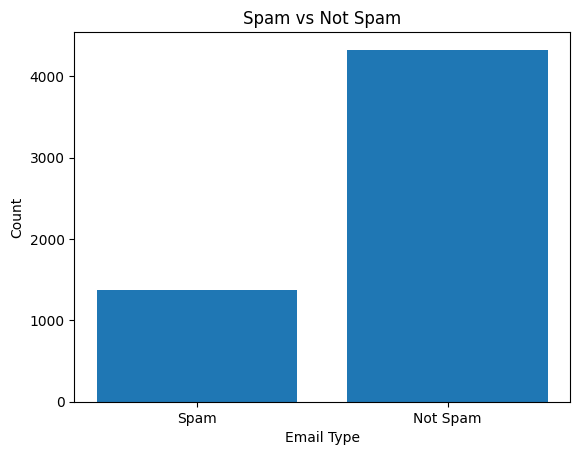

In [ ]:
# Let's visualize the data

# Count the number of spam and non-spam emails
spam_count = df['spam'].value_counts()[1]
non_spam_count = df['spam'].value_counts()[0]

# Create a bar chart
plt.bar(['Spam', 'Not Spam'], [spam_count, non_spam_count])
plt.title('Spam vs Not Spam')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.show()

The data is imbalanced, with significantly more non-spam emails than spam emails. This could potentially affect the performance of a machine learning model trained on this data, as it may be biased towards predicting non-spam emails.

### Text Processing

In [ ]:
# Import Libraries
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

# Download packages
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
random_sample = df['text'].sample(3)
for text in random_sample:
  print(text,'\n')

Subject: save your money buy getting this thing here  you have not tried cialls yet ?  than you cannot even imagine what it is like to be a real man in bed !  the thing is that a great errrectlon is provided for you exactly when you want .  ciaiis has a iot of advantages over viaqra  - the effect lasts 36 hours !  - you are ready to start within just 10 minutes !  - you can mix it with alcohoi ! we ship to any country !  get it riqht now ! .  

Subject: christmas baskets  kevin :  i do not know who half of these people are !  my list would be :  move team  susan kennedy and judy schlesinger ( order all of our subscriptions )  demonica lipscomb ( video scheduling - should include stuart )  dave delainey  mail room  help desk ( our tech is : doug doring )  facilities help desk ( don ' t know who )  marriott ( trina - she takes care of all the lunches we order )  i don ' t think we need to give the ozarka guy one , we have several  who deliver down here , it is not always the same one .  

In [ ]:
# Preprocessing function
def preprocessing_text(text):
  # Lowercase the text
  text = text.lower()

  # Tokenize the text
  tokens = word_tokenize(text)

  # Remove punctuation and non-alphanumeric characters
  tokens = [word for word in tokens if word.isalnum()]

  # Remove stopwords
  stop_words = set(stopwords.words('english'))
  tokens = [word for word in tokens if word not in stop_words]

  # Initialize steming
  stemmer = PorterStemmer()
  tokens = [stemmer.stem(word) for word in tokens]

  # Join tokens back into a processed text
  processed_text = ' '.join(tokens)

  return processed_text

In [ ]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Assign a new column with processed text
df['processed_text'] = df['text'].apply(preprocessing_text)
df['processed_text'].sample(5)

,processed_text
2860,subject dhabol jeff shall forward shortli copi...
998,subject save money buy get thing tri ciall yet...
764,subject messag subject deliv bastid laurent ba...
4213,subject real option present thank comment gran...
2151,subject cal berkeley gener present confirm 10 ...


### Split data `(train & test)` and Vectorize the text data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Let's visualize the number of spam and non-spam emails in the train and test sets.
spam_counts = [y_train.value_counts()[1], y_test.value_counts()[1]]
non_spam_counts = [y_train.value_counts()[0], y_test.value_counts()[0]]

x_labels = ['Train', 'Test']

plt.bar(x_labels, spam_counts, label='Spam')
plt.bar(x_labels, non_spam_counts, bottom=spam_counts, label='Not Spam')
plt.title('Spam vs Not Spam in Train and Test Sets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.legend()
plt.show()

NameError: name 'y_train' is not defined

In [ ]:
# Vectorize the text data
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"X_train_vec: {X_train_vec.toarray().shape}")
print(f"X_test_vec: {X_test_vec.toarray().shape}")

### Convert vectorized data and labels into PyTorch tensor

In [ ]:
import torch
# Device agnostic code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

In [ ]:
# Convert data & labels into PyTorch tensor
X_train_tensor = torch.tensor(X_train_vec.toarray(),
                             dtype=torch.float32,
                             device=device)
y_train_tensor = torch.tensor(y_train.values,
                             dtype=torch.float32,
                             device=device)
X_test_tensor = torch.tensor(X_test_vec.toarray(),
                             dtype=torch.float32,
                             device=device)
y_test_tensor = torch.tensor(y_test.values,
                             dtype=torch.float32,
                             device=device)

### Create TensorDatasets and DataLoaders

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                         shuffle=True)
test_loader = DataLoader(test_dataset,
                        batch_size=batch_size,
                        shuffle=True)

### Let's build a simple feedforward neural network model

In [ ]:
from torch import nn

# Define model
class SpamFilter(nn.Module):
    def __init__(self, input_size):
        super(SpamFilter, self).__init__()
        self.layer1 = nn.Linear(in_features=input_size,
                               out_features=128)

        self.layer2 = nn.Linear(in_features=128,
                               out_features=64 )

        self.layer3 = nn.Linear(in_features=64,
                               out_features=1 )

    def forward(self, x):
        out = torch.relu(self.layer1(x))
        out = torch.relu(self.layer2(out))
        out = torch.sigmoid(self.layer3(out))
        return out

### Initialize model & define loss function and optimizer

In [ ]:
# Initialize the model
input_size = X_train_vec.shape[1]
model0 = SpamFilter(input_size).to(device)

In [ ]:
# loss function
criterion = nn.BCELoss()

# optimizer
optimizer = torch.optim.Adam(params=model0.parameters(),
                            lr=0.001)

### Let's build a training loop & evaluate our model

In [ ]:
# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model0.train()  # Set the model to training mode
    running_loss = 0.0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model0(inputs)

        loss = criterion(outputs, labels.unsqueeze(1))
        loss.backward()

        optimizer.step()

        running_loss += loss.item()


    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss}')

In [ ]:
# Evaluation
model0.eval()

correct = 0
total = 0

with torch.inference_mode():
    for inputs, labels in test_loader:
        outputs = model0(inputs)
        predicted = (outputs > 0.5).float()

        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(dim=1)).sum().item()

accuracy = correct / total
print('Test Accuarcy: {:.2f}%'.format(100 * accuracy))


### Use trained model to classify new emails

In [ ]:
spam_email = """Subject: Urgent: Claim Your Prize Now!

Congratulations! You have been selected as the lucky winner of our grand prize giveaway! Claim your prize now by clicking on the link below. Don't miss out on this amazing opportunity!

Click here to claim your prize: superlottery@gmail.com

Hurry, this offer is only available for a limited time!

Best Regards,
Spammy Marketing Team
"""

non_spam_email = """Subject: Meeting Agenda for Tomorrow

Hi Team,

I hope this email finds you well. I wanted to remind everyone about the meeting scheduled for tomorrow at 10:00 AM. Below is the agenda:

1. Review of project milestones
2. Discussion on upcoming deadlines
3. Any other business

Please come prepared with any updates or questions you may have. Looking forward to a productive meeting.

Best regards,
Mr. Bannerjee
"""
def classify_email(email_text):
    # Preprocess the email
    preprocessed_email = preprocessing_text(email_text)

    # Vectorize the preperocessed email
    vectorized_email = vectorizer.transform([preprocessed_email])

    # Convert the vectorized email into PyTorch tensor
    email_tensor = torch.tensor(vectorized_email.toarray(),
                               dtype=torch.float32,
                               device=device)

    # Use the model for inference
    output = model0(email_tensor)

    # If the email is spam ot not
    if output > 0.5:
        return "spam"
    else:
        return "not spam"


In [ ]:
# List of emails
email_examples = [non_spam_email, non_spam_email]

for i, email_text in enumerate(email_examples, start=1):
    classification = classify_email(email_text)
    print(f"Email {i} is classified as {classification}")

### Save our classification model

In [ ]:
# Saving PyTorch Model
from pathlib import Path

# Create model's directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save path
MODEL_NAME = "Spam_Classification.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME

# Save the model's state dict
print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model0.state_dict(), f=MODEL_SAVE_PATH)

# Hometask: happy-angry
